# Stat 220, Unit 1 Homework: Statistical Inference

Answer each problem in the cell(s) provided. Replace *Your answer* with your response
for written parts, and put code in the empty code cells.

The first problem is a **simulation lab**: you build a world where you already know the truth, so
you can watch the machinery work. The next three are **real data with real decisions attached**.
The last one asks what you are and are not entitled to conclude.

Throughout, a correct number with a wrong interpretation earns very little. Say what the number
means, and say what it does not mean.

**Data** (real, all from the course server):

- `https://richardson.byu.edu/220/bikes.csv`: 365 days of bike-rental counts with weather.
- `https://richardson.byu.edu/220/rent.csv`: 4,743 rental listings across six cities.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(220)
bikes = pd.read_csv("https://richardson.byu.edu/220/bikes.csv")
rent = pd.read_csv("https://richardson.byu.edu/220/rent.csv")
print(bikes.shape, rent.shape)
bikes.head()

(365, 8) (4743, 9)


,Count,Temperature,Humidity,Wind_speed,Visibility,Rainfall,Seasons,Holiday
0,449,1.7,23,1.4,2000,0.0,Winter,No Holiday
1,479,4.3,41,1.3,1666,0.0,Winter,No Holiday
2,333,5.8,85,1.7,349,0.0,Winter,No Holiday
3,393,-0.3,38,4.8,1823,0.0,Winter,No Holiday
4,321,-2.3,25,0.0,1962,0.0,Winter,No Holiday


**Problem 1.** *Simulation lab: what a p-value is.* Here you control the truth, so you can check
what the machinery does. Use `rng` for everything.

Part a. Write a function `run_studies(n_studies, n, true_diff, sd=1.0)` that simulates
`n_studies` experiments. Each experiment draws two independent groups of size `n` from normal
distributions whose means differ by `true_diff`, runs a Welch two-sample $t$-test, and returns the
array of p-values.

In [2]:
def run_studies(n_studies, n, true_diff, sd=1.0):
    p_values = []

    for _ in range(n_studies):
        group1 = rng.normal(0, sd, n)
        group2 = rng.normal(true_diff, sd, n)

        result = stats.ttest_ind(group1, group2, equal_var=False)
        p_values.append(result.pvalue)

    return np.array(p_values)

Part b. Run 5,000 studies with `true_diff = 0` and $n = 30$, so that **nothing is really
going on**. Plot a histogram of the p-values, and report the fraction below 0.05.

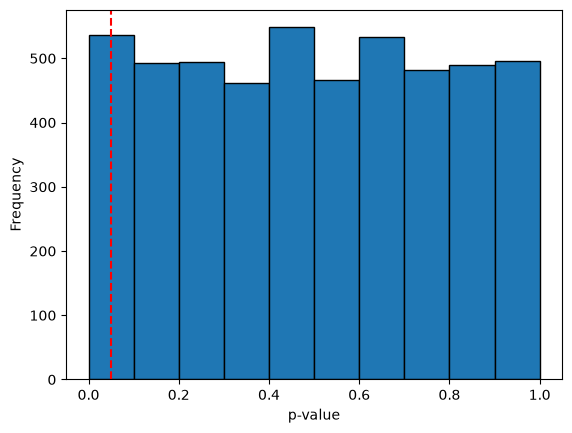

Fraction below 0.05: 0.049


In [3]:
test_p_value = run_studies(5000, 30, 0)

plt.hist(test_p_value, bins=10, edgecolor="black")
plt.axvline(0.05, color="red", linestyle="--")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

fraction = np.mean(test_p_value < 0.05) # this returns [false, false, true, false, true] so mean is calculated to get fraction
print(f"Fraction below 0.05: {fraction:.3f}")

# I also don't understand why the p value changes so much if it's the same differences and variance

Part c. The histogram should look flat. Explain in 2 to 3 sentences why the p-values are
uniform when the null is true, and what that implies about the meaning of "$p < 0.05$".

_Your answer:_

Because the true_diff is 0 the sample groups are the same, and the null hypothesis is true. This study was run so many times that by randomness and chance all p-values were hit, so it became uniform. This also means that a p < 0.05 does not mean significance in this case because it was hit by randomness. 



Part d. Now set `true_diff = 0.5` and compute the fraction of studies that reach $p<0.05$
for $n = 10, 30, 100, 400$. This fraction is the **power**. Present the four numbers in a small
table and describe the pattern.

In [ ]:
def compute_fractions(n, diff, n_studies):
    fractions = []
    for size in n:
        p_values = run_studies(n_studies, size, diff)
        fractions.append(np.mean(p_values < 0.05))

    return fractions

fraction_values = compute_fractions([10, 30, 100, 400], 0.5, 5000)

table = pd.DataFrame({'P-Value Fractions': fraction_values, 'Sample Size': [10, 30, 100, 400]})
table


,P-Value Fractions,Sample Size
0,0.2006,10
1,0.4804,30
2,0.9458,100
3,1.0000,400


The Pattern in problem part d:

As the sample size grows, the standard error decreases. In the t-test formula of signal/noise, if the estimated difference remains the same, but the standard error decreases, the t-test grows producing smaller p-values. 

Part e. Keep $n = 15$ and `true_diff = 0.3`. Among only the studies that reached
significance, compute the average estimated difference. Compare it to the true 0.3 and explain the
phenomenon you have just measured, and why it makes small significant studies untrustworthy.

In [7]:
# Compute mean of only the p-values below 0.05
def get_significance_mean(n_studies, n, true_diff, sd=1.0):
    significant_diffs = []

    for _ in range(n_studies):
        group1 = rng.normal(0, sd, n)
        group2 = rng.normal(true_diff, sd, n)

        result = stats.ttest_ind(group1, group2, equal_var=False)

        if result.pvalue < 0.05:
            significant_diffs.append(group2.mean() - group1.mean())

    return np.mean(significant_diffs), len(significant_diffs)

avg_diff, n_significant = get_significance_mean(5000, 15, 0.3)
print("Significant studies:", n_significant)
print("Average estimated difference:", avg_diff)

Significant studies: 599
Average estimated difference: 0.8441831926003452


Explanation for part e:
Firstly, I calculate the mean of estimated differences on all samples, not excluding non-significant runs. The average estimated difference was close to the true_diff (0.30899893125418). After taking the mean of only the significant estimated differences, the average estimated difference was 0.8441831926003452, very difference from the true difference. When all samples are included, positive and negative sampling errors tend to balance out. However, when taking only the significant samples, because the sample size is so small, the average estimated difference is less precise. 

Part f. Simulate the peeking problem: run experiments with **no real effect** where you
test after every 20 new observations up to $n = 500$ and stop the moment $p < 0.05$. Across 2,000
such experiments, what fraction produce a "significant" result? Explain the gap between that
number and 0.05.

In [8]:
significant_results = []

for _ in range(2000):
    # Generate all observations for one experiment
    group1 = rng.normal(0, 1, 500)
    group2 = rng.normal(0, 1, 500)

    became_significant = False

    # Peek after every 20 observations
    for n in range(20, 501, 20):
        result = stats.ttest_ind(
            group1[:n],
            group2[:n],
            equal_var=False
        )

        if result.pvalue < 0.05:
            became_significant = True
            break

    significant_results.append(became_significant)

fraction_significant = np.mean(significant_results)
print(fraction_significant)
    



0.268


Explanation for part f: 
A p-value of 0.05 means that it has a 5% false positive rate (saying it's significant when it's not). However, after peeking many times, the significance rate increase by 0.268. This increased the false-positive rate by 0.218. This happens because stopping as soon as \(p<0.05\) gives random variation many opportunities to appear significant.

**Problem 2.** *Real data: do holidays change bike ridership?* Use `bikes`. The operations team
wants to know whether to staff differently on holidays. `Count` is the day's rentals and `Holiday`
marks the day type.

Part a. Report the number of days, mean, and standard deviation of `Count` for each level
of `Holiday`. Plot the two distributions side by side (boxplot or overlaid histograms).

In [12]:
bikes

,Count,Temperature,Humidity,Wind_speed,Visibility,Rainfall,Seasons,Holiday
0,449,1.7,23,1.4,2000,0.0,Winter,No Holiday
1,479,4.3,41,1.3,1666,0.0,Winter,No Holiday
2,333,5.8,85,1.7,349,0.0,Winter,No Holiday
3,393,-0.3,38,4.8,1823,0.0,Winter,No Holiday
4,321,-2.3,25,0.0,1962,0.0,Winter,No Holiday
...,...,...,...,...,...,...,...,...
360,752,9.1,57,1.1,562,0.0,Autumn,No Holiday
361,672,9.3,61,1.5,390,0.0,Autumn,No Holiday
362,635,7.9,14,1.7,1688,0.0,Autumn,No Holiday
363,661,5.6,27,0.3,1522,0.0,Autumn,No Holiday


,days,mean,standard_deviation
Holiday,,,
Holiday,18,621.611111,587.343585
No Holiday,347,703.478386,421.790406


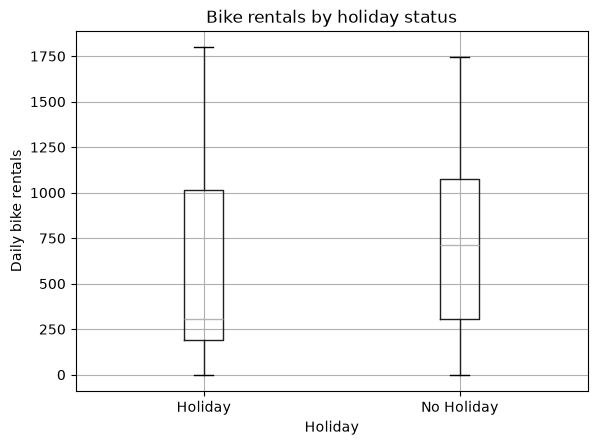

In [9]:
# Number of days, mean, and standard deviation
summary = bikes.groupby("Holiday")["Count"].agg(
    days="count",
    mean="mean",
    standard_deviation="std"
)

display(summary)

# Side-by-side distributions
bikes.boxplot(column="Count", by="Holiday")
plt.xlabel("Holiday")
plt.ylabel("Daily bike rentals")
plt.title("Bike rentals by holiday status")
plt.suptitle("")
plt.show()

Part b. Run a Welch two-sample $t$-test comparing the two groups. Report the difference in
means, the $t$-statistic, the p-value, and a 95% confidence interval for the difference.

In [13]:
holiday = bikes.loc[bikes["Holiday"] == 'Holiday', "Count"].dropna()
nonholiday = bikes.loc[bikes["Holiday"] == 'No Holiday', "Count"].dropna()

# Difference in sample means
mean_diff = holiday.mean() - nonholiday.mean()

# Welch two-sample t-test
result = stats.ttest_ind(holiday, nonholiday, equal_var=False)

# 95% confidence interval for the difference
ci = result.confidence_interval(confidence_level=0.95)

print("Difference in means:", mean_diff)
print("t-statistic:", result.statistic)
print("p-value:", result.pvalue)
print("95% confidence interval:", (ci.low, ci.high))

Difference in means: -81.86727505603585
t-statistic: -0.5836085356740244
p-value: 0.5667571158807455
95% confidence interval: (np.float64(-376.6728681959455), np.float64(212.9383180838738))


Part c. The result is not significant. Your manager writes: *"Confirmed, holidays make no difference. Staff them normally."* Using your confidence interval, explain in 3 to 4 sentences
why that conclusion is not supported, and what the data actually establishes.

_Your answer:_



Because the confidence interval passes through 0, this means that having no difference is a value that could happen. This means that the p-value result of having no difference could come from the possibility of the result from the confidence internval. This means that there isn't enough evidence is prove there is a difference or to prove that there is none. 

Part d. Quantify the problem: by simulation, estimate the power this comparison would have
to detect a true difference of 150 rentals per day, given the group sizes and standard deviations
you observed. (Simulate from normals with those parameters and count how often $p<0.05$.) What
does the number tell you?

In [15]:
holiday = bikes.loc[bikes["Holiday"] == "Holiday", "Count"].dropna()
nonholiday = bikes.loc[bikes["Holiday"] == "No Holiday", "Count"].dropna()

n_holiday = len(holiday)
n_nonholiday = len(nonholiday)

sd_holiday = holiday.std()
sd_nonholiday = nonholiday.std()

n_simulations = 10_000
significant_results = 0

for _ in range(n_simulations):
    # True means differ by 150
    simulated_holiday = rng.normal(
        loc=150, scale=sd_holiday, size=n_holiday
    )
    simulated_nonholiday = rng.normal(
        loc=0, scale=sd_nonholiday, size=n_nonholiday
    )

    test = stats.ttest_ind(
        simulated_holiday,
        simulated_nonholiday,
        equal_var=False
    )

    if test.pvalue < 0.05:
        significant_results += 1

power = significant_results / n_simulations
print("Estimated power:", power)

Estimated power: 0.1779


Explanation for Part d:
The result is that the power is 0.1779. This means that it detects 17.79% of the times it was truly significant, even though it was significant all the time. 

Part e. How many holidays would you need in the data to reach 80% power against a
150-rental difference? Find it by simulating a range of holiday counts. Given that a year contains
a fixed number of holidays, what does your answer imply about ever settling this question with one
year of data?

Holidays needed: 150
Estimated power: 0.8088


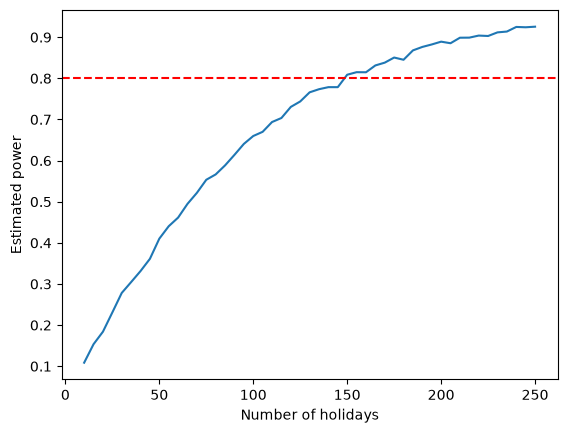

In [16]:
rng = np.random.default_rng(220)

n_simulations = 5000
holiday_counts = range(10, 251, 5)
powers = []

for n_h in holiday_counts:
    simulated_holiday = rng.normal(
        loc=150,
        scale=sd_holiday,
        size=(n_simulations, n_h)
    )

    simulated_nonholiday = rng.normal(
        loc=0,
        scale=sd_nonholiday,
        size=(n_simulations, n_nonholiday)
    )

    tests = stats.ttest_ind(
        simulated_holiday,
        simulated_nonholiday,
        axis=1,
        equal_var=False
    )

    power = np.mean(tests.pvalue < 0.05)
    powers.append(power)

# Find the first tested count reaching 80% power
for n_h, power in zip(holiday_counts, powers):
    if power >= 0.80:
        print("Holidays needed:", n_h)
        print("Estimated power:", power)
        break

# Plot power against holiday count
plt.plot(list(holiday_counts), powers)
plt.axhline(0.80, color="red", linestyle="--")
plt.xlabel("Number of holidays")
plt.ylabel("Estimated power")
plt.show()

The power hit 80% at around 150 holidays. This means that study should run for about 8 years to have enough evidence to make a conclusion. 

**Problem 3.** *Real data: furnished apartments rent for more.* Use `rent`. A property manager
asks how much extra to charge for furnishing a unit.

In [17]:
rent

,BHK,Rent,Size,AreaType,City,FurnishingStatus,Preferred,Bathroom,Contact
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...
4738,2,15000,1000,Carpet Area,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4739,3,29000,2000,Super Area,Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4740,3,35000,1750,Carpet Area,Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4741,3,45000,1500,Carpet Area,Hyderabad,Semi-Furnished,Family,2,Contact Agent


Part a. Compare `Rent` for `FurnishingStatus == "Furnished"` versus `"Unfurnished"`.
Report both sample sizes, both means, the difference, the $t$-statistic, and the p-value.

In [18]:
furnished = rent.loc[
    rent["FurnishingStatus"] == "Furnished", "Rent"
].dropna()

unfurnished = rent.loc[
    rent["FurnishingStatus"] == "Unfurnished", "Rent"
].dropna()

n_furnished = len(furnished)
n_unfurnished = len(unfurnished)

mean_furnished = furnished.mean()
mean_unfurnished = unfurnished.mean()

# Difference is furnished minus unfurnished
mean_difference = mean_furnished - mean_unfurnished

test = stats.ttest_ind(
    furnished,
    unfurnished,
    equal_var=False
)

print("Furnished sample size:", n_furnished)
print("Unfurnished sample size:", n_unfurnished)
print("Furnished mean:", mean_furnished)
print("Unfurnished mean:", mean_unfurnished)
print("Difference in means:", mean_difference)
print("t-statistic:", test.statistic)
print("p-value:", test.pvalue)

Furnished sample size: 679
Unfurnished sample size: 1813
Furnished mean: 56170.85125184094
Unfurnished mean: 22480.07115278544
Difference in means: 33690.7800990555
t-statistic: 10.513973395325348
p-value: 2.9025866170815562e-24


Part b. The p-value is astronomically small. Explain what that does and does not tell you.
In particular, state whether it says anything about **how much** furnishing is worth.

_Your answer:_



A very small p-value means that there is strong evidence that the means of furnished and unfurnished apartments differ. However, it does not say how much they differ by, and how big their sample sizes are. 

Part c. Report a 95% confidence interval for the difference in mean rent, and compare the
information it carries to the p-value from Part a. Which would you put in a memo, and why?

In [19]:
ci = test.confidence_interval(confidence_level=0.95)

print("Mean difference:", mean_difference)
print("95% confidence interval:", (ci.low, ci.high))

Mean difference: 33690.7800990555
95% confidence interval: (np.float64(27400.504081386014), np.float64(39981.056116724976))


Explanation Part c:
The p-value says that there is strong evidence that furnished and unfurnished mean apartment rents differ, but they don't say how much they differ, which would be important information for a properity manager. I would add the 95% confidence interval in the memo because it gives more information about how much the means differ.

Part d. Furnished units are not otherwise identical to unfurnished ones. Compare the two
groups on `Size`, `BHK`, and `City` composition. Report at least two ways they differ.

In [20]:
comparison = rent[
    rent["FurnishingStatus"].isin(["Furnished", "Unfurnished"])
]

# Compare Size and BHK
numeric_comparison = comparison.groupby("FurnishingStatus")[
    ["Size", "BHK"]
].agg(["mean", "median"])

display(numeric_comparison)

# Compare city composition using percentages within each group
city_comparison = pd.crosstab(
    comparison["City"],
    comparison["FurnishingStatus"],
    normalize="columns"
) * 100

display(city_comparison.round(1))

Size              BHK       
                         mean median      mean median
FurnishingStatus                                     
Furnished         1047.456554  937.0  2.169367    2.0
Unfurnished        801.703806  700.0  1.907887    2.0

FurnishingStatus,Furnished,Unfurnished
City,,
Bangalore,13.4,11.6
Chennai,11.8,20.0
Delhi,14.3,12.7
Hyderabad,16.3,19.5
Kolkata,9.0,17.7
Mumbai,35.2,18.5


Differences between furnished and unfurnished:
- Furnished apartments have a bigger mean size (furnished -> 1047 and unfurnished -> 801)
- Chennai has more unfurnished than furnished apartments

Part e. Repeat the furnished-versus-unfurnished comparison **within a single city and a
single `BHK` level** (choose ones with enough listings). Report the difference and its interval.
How does it compare to the raw difference from Part a, and what does that tell the property
manager about the number they should actually use?

In [ ]:
counts = comparison.groupby(
    ["City", "BHK", "FurnishingStatus"]
).size().unstack(fill_value=0)

counts["smallest_group"] = counts[
    ["Furnished", "Unfurnished"]
].min(axis=1)

# display(counts.sort_values("smallest_group", ascending=False).head())

chosen_city, chosen_bhk = counts["smallest_group"].idxmax()

subset = comparison[
    (comparison["City"] == chosen_city) &
    (comparison["BHK"] == chosen_bhk)
]

furnished_sub = subset.loc[
    subset["FurnishingStatus"] == "Furnished", "Rent"
].dropna()

unfurnished_sub = subset.loc[
    subset["FurnishingStatus"] == "Unfurnished", "Rent"
].dropna()

test_sub = stats.ttest_ind(
    furnished_sub,
    unfurnished_sub,
    equal_var=False
)

difference_sub = furnished_sub.mean() - unfurnished_sub.mean()
ci_sub = test_sub.confidence_interval(confidence_level=0.95)

print("City:", chosen_city)
print("BHK:", chosen_bhk)
print("Sample sizes:", len(furnished_sub), len(unfurnished_sub))
print("Mean difference:", difference_sub)
print("95% confidence interval:", (ci_sub.low, ci_sub.high))
print("Raw difference from Part a:", mean_difference)

FurnishingStatus  Furnished  Unfurnished  smallest_group
City      BHK                                           
Mumbai    2              86          130              86
          1              59          137              59
Hyderabad 2              54          219              54
Mumbai    3              70           53              53
Bangalore 2              48          100              48

City: Mumbai
BHK: 2
Sample sizes: 86 130
Mean difference: 25082.03846153846
95% confidence interval: (np.float64(14231.327123320418), np.float64(35932.74979975651))
Raw difference from Part a: 33690.7800990555


I chose city Mumbai with 2 BHK because it has plenty of both furnished and unfurnished listings. It had 86 furnished and 130 unfurnished, all other cities had around 50 unfurnished with 100-200 furnished. Mumbai with 2 BHK had a mean difference of 25082, with a 95% CI of 14231 and 35932. This is far less than the difference from all the cities combined with is 33690.78. This means that maybe the properity manager should look at specific cities to get a more precise value.  

**Problem 4.** *When the test is quietly wrong.* Both datasets violate a $t$-test assumption.
Find the damage.

Part a. Plot `Rent` and describe its shape. Then compare the mean and median. Which
assumption of the $t$-test is under strain here, and does the sample size rescue it?

In [26]:
rent

,BHK,Rent,Size,AreaType,City,FurnishingStatus,Preferred,Bathroom,Contact
0,2,10000,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...
4738,2,15000,1000,Carpet Area,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4739,3,29000,2000,Super Area,Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4740,3,35000,1750,Carpet Area,Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4741,3,45000,1500,Carpet Area,Hyderabad,Semi-Furnished,Family,2,Contact Agent


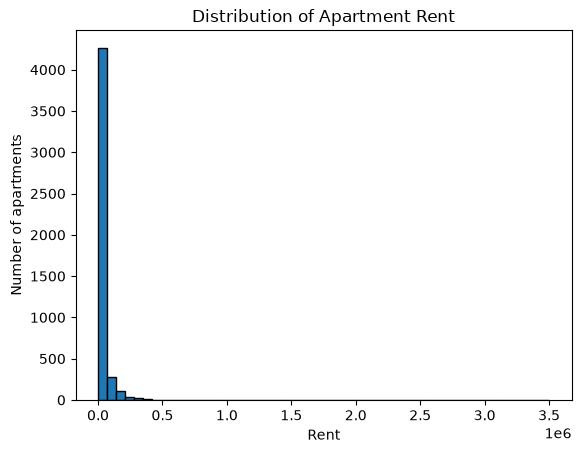

Sample size: 4743
Mean: 35009.99789162977
Median: 16000.0


In [25]:
rent_values = rent["Rent"].dropna()

plt.hist(rent_values, bins=50, edgecolor="black")
plt.xlabel("Rent")
plt.ylabel("Number of apartments")
plt.title("Distribution of Apartment Rent")
plt.show()

print("Sample size:", len(rent_values))
print("Mean:", rent_values.mean())
print("Median:", rent_values.median())

Rent is strongly right-skewed and its mean is larger than its median. However, the sample size is large enough that the Central Limit Theorem can apply here and doesn't strain the t-test.

Part b. Redo the Problem 3a comparison three ways, all of them $t$-tests: on the raw
`Rent`, on $\log(\text{Rent})$, and on the raw rents after dropping the most extreme 1% of
listings. Report all three and explain what each one is actually estimating, and why they do not
answer quite the same question. (We get a fourth and better way, the bootstrap, in Unit 10.)

In [27]:
def welch_results(group1, group2):
    test = stats.ttest_ind(group1, group2, equal_var=False)
    return {
        "difference": group1.mean() - group2.mean(),
        "t-statistic": test.statistic,
        "p-value": test.pvalue
    }

# 1. Raw rent
raw_results = welch_results(furnished, unfurnished)

# 2. Log rent
log_furnished = np.log(furnished)
log_unfurnished = np.log(unfurnished)

log_results = welch_results(log_furnished, log_unfurnished)

# Convert log difference to a percentage difference
rent_ratio = np.exp(log_results["difference"])
percent_difference = (rent_ratio - 1) * 100

# 3. Remove the highest 1% of rents
cutoff = comparison["Rent"].quantile(0.99)
trimmed = comparison[comparison["Rent"] <= cutoff]

trimmed_furnished = trimmed.loc[
    trimmed["FurnishingStatus"] == "Furnished", "Rent"
]

trimmed_unfurnished = trimmed.loc[
    trimmed["FurnishingStatus"] == "Unfurnished", "Rent"
]

trimmed_results = welch_results(
    trimmed_furnished,
    trimmed_unfurnished
)

print("Raw rent:", raw_results)
print("Log rent:", log_results)
print("Log-scale percentage difference:", percent_difference)
print("Highest 1% cutoff:", cutoff)
print("Trimmed rent:", trimmed_results)

Raw rent: {'difference': np.float64(33690.7800990555), 't-statistic': np.float64(10.513973395325348), 'p-value': np.float64(2.9025866170815562e-24)}
Log rent: {'difference': np.float64(0.7774106196498742), 't-statistic': np.float64(17.664426299265422), 'p-value': np.float64(4.208098545655751e-61)}
Log-scale percentage difference: 117.58309110378246
Highest 1% cutoff: 280000.0
Trimmed rent: {'difference': np.float64(25888.560596936026), 't-statistic': np.float64(12.27296490277496), 'p-value': np.float64(7.89333717732004e-32)}


1. The raw test estimates an arithmetic difference, and it's sensitive to outliers, or extremely expensive listings.
2. The log test estimates a difference in mean log rent. After exponentiating, it describes a ratio or approximate percentage difference in typical rent.
3. The trimmed test estimates the less expensive apartments because it excludes the 1% most expensive, so it does not describe the complete market

All three of them compare different scales and populations. 

Part c. Now the `bikes` data. Compute the lag-1 autocorrelation of `Count` across the
year (`bikes["Count"].autocorr(1)`). Report it and explain what it means about the independence
assumption behind Problem 2.

In [28]:
lag1_autocorrelation = bikes["Count"].autocorr(lag=1)

print("Lag-1 autocorrelation:", lag1_autocorrelation)

Lag-1 autocorrelation: 0.500500830324923


The Lag-1 autocorrelation is 0.5, which is a positive number. This means that a high bike rider day tends to be followed by another high bike rider day. This shows that this dataset is not independent and may make t-test and p-values less reliable.

Part d. Demonstrate the damage by simulation: generate two groups of 200 "days" each with
**no real difference** but with each day correlated with the previous one (for example
$x_t = 0.5x_{t-1} + \varepsilon_t$). Across 2,000 such experiments, what fraction produce
$p < 0.05$? Compare it to the 5% you asked for.

In [29]:
rng = np.random.default_rng(220)

def simulate_ar1(n, rho=0.5):
    x = np.zeros(n)
    errors = rng.normal(0, 1, n)

    for t in range(1, n):
        x[t] = rho * x[t - 1] + errors[t]

    return x

n_experiments = 2000
significant = 0

for _ in range(n_experiments):
    group1 = simulate_ar1(200)
    group2 = simulate_ar1(200)

    test = stats.ttest_ind(
        group1,
        group2,
        equal_var=False
    )

    if test.pvalue < 0.05:
        significant += 1

false_positive_rate = significant / n_experiments

print("Fraction with p < 0.05:", false_positive_rate)
print("Requested false-positive rate:", 0.05)

Fraction with p < 0.05: 0.283
Requested false-positive rate: 0.05


On 28% of times it said that p < 0.05, compared with the intended 5% (no real difference). Because this is not an independent data, the t-test produces too many false-positive results.

Part e. In 2 to 3 sentences, state which of the two problems, skew or dependence, you would worry about more in a real analysis, and why.

I would worry more about dependence because it can give too many false-positive results. These false-positive errors can be harmful conclusions in certain studies. Increasing the sample size can make the central limit theorem applicable, though it does not eliminate the skewness. Dependence is harder to address because a larger sample size does not provide new information as the t-test assumes. 

_Your answer:_



**Problem 5.** *What can and cannot be said.* No new computation is required here. This is the part that
separates an analyst from a calculator.

Part a. Write the two-sentence result statement you would send the operations team about
holidays and bike ridership (Problem 2). It must be honest about both what you found and what
remains unknown.

_Your answer:_



The statistical test failed to find clear evidence of difference in holidays and no holidays. However, small number of holiday data compared to no holiday data, a wide CI and low power show that differences remain plausible, and more data is needed.

Part b. Write the two-sentence statement you would send the property manager about
furnishing (Problem 3), including the number you would recommend and the caveat attached to it.

_Your answer:_



Overall, furnished and unfurnished apartments have a large rent difference of 33690.78, with a 95% CI from 27400.5 to 39981, however, apartments in Mumbai with 2 BHK had a 25082 rent difference with a 95% CI from 14231 to 35932. Because looking at a specific city gave a more specific value, it is better to look at more detailed parts of the dataset. 

Part c. For each of the following claims, say whether your analyses support it, and if
not, what evidence would be required. (i) *Holidays do not affect ridership.* (ii) *Furnishing a
unit causes rent to rise by the amount you found in Problem 3a.* (iii) *The furnishing result is
more trustworthy than the holiday result because its p-value is smaller.*

_Your answer:_



1. Analyses does not support this yet because the dataset seems to be independent and it needs more evidence on holidays.

2. Analyses does not fully suport this because the amount rent rises depends on the city and on other unknown factors. 

3. The analysis does not support this because trustworthiness depedens on more than a small p-value (assumptions, study design, power, etc.). 


Part d. A colleague proposes settling the holiday question by testing every weather
variable, day type, and season in the dataset and reporting whichever comparisons come out
significant. Explain what is wrong with this, and estimate roughly how many "significant" results
they would find by chance if they ran 40 such tests on pure noise.

_Your answer:_



The problem with the bike dataset is not only lack of holiday sample size, but also of dependency. Even if every null hypothesis were true, each test would have a 5% chance of being significant. With 40 tests, we would expect approximately 2 significant results purely by chance.

Part e. Across this assignment you used p-values, confidence intervals, effect sizes, and
power. Rank them by how useful they were for making an actual decision, and defend your
ranking in 3 to 4 sentences.

_Your answer:_



1. Effect sizes
2. Confidence intervals
3. Power
4. p-values

There was a lot of information coming from the sample sizes, for example skewness and central limit theorem applicabilaty, and fair representation of data. 
Confidence intervals and power gave more information about the data that was hidden in the p-value results, and also showed whether the p-value was trustworthy or not. P-values were misleading at times and did not give enough information about the dataset. 